
# Edge AI Assignment: Neural Network from Scratch (Checkerboard Classification)

## Objective
Build a simple neural network **from scratch (no ML libraries)** to classify a 2D checkerboard pattern.

You will:
- Implement forward propagation
- Implement backpropagation
- Train a small neural network
- Visualize the decision boundary

---

## Dataset Concept
We generate (x, y) points and assign labels based on a checkerboard pattern.

This is a **non-linear classification problem** (like XOR, but extended to 2D).


In [9]:

import numpy as np
import matplotlib.pyplot as plt


## Step 1: Generate Checkerboard Data

In [10]:

def generate_data(n_samples=5000, k=4):
    X = np.random.uniform(-1, 1, (n_samples, 2))

    # Checkerboard labels
    y = ((np.floor((X[:,0]+1)*k) + np.floor((X[:,1]+1)*k)) % 2)

    return X, y.reshape(-1, 1)

X, y = generate_data()


## Visualize Dataset

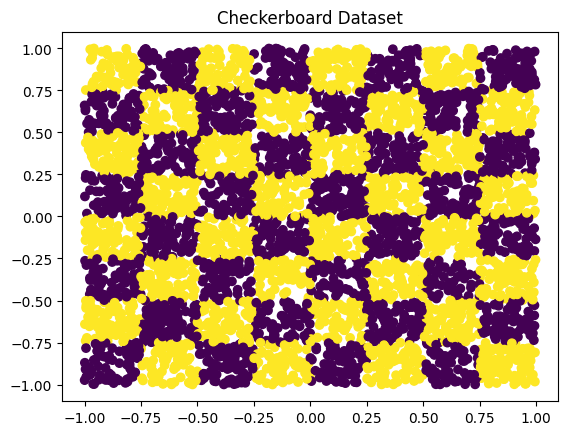

In [11]:

plt.scatter(X[:,0], X[:,1], c=y.flatten())
plt.title("Checkerboard Dataset")
plt.show()



## Step 2: Build Neural Network

Architecture:
- Input: 2 neurons (x, y)
- Hidden: YOU DECIDE
- Output: 1 neuron (sigmoid)

Fill in missing parts.


In [12]:

# Initialize weights
def init_params(input_size, hidden_size, output_size):
    W1 = np.random.randn(input_size, hidden_size)
    b1 = np.zeros((1, hidden_size))

    W2 = np.random.randn(hidden_size, output_size)
    b2 = np.zeros((1, output_size))

    return W1, b1, W2, b2


## Activation Functions

In [13]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)
    pass


## Forward Pass

In [14]:

def forward(X, W1, b1, W2, b2):
    # TODO:
    # 1. Hidden layer linear combination
    hidden_input = np.dot(X,W1)+b1
    # 2. Activation
    hidden_output = np.sigmoid( hidden_input )
    # 3. Output layer
    final_input = np.dot(hidden_output, W2)+b2
    final_output = np.sigmoid( final_input )
    # 4. Return output + intermediates
    return hidden_input, hidden_output, final_input, final_output
    pass


## Loss Function

In [15]:

def compute_loss(y_true, y_pred):
    # TODO: Binary cross-entropy
    pass


## Backpropagation

X is the input, y error W1, b1, W2, b2 are the original weights

In [16]:

def backward(X, y, W1, b1, W2, b2, cache):
    # TODO:
    # Compute gradients for all parameters
    pass


## Training Loop

   Train the network using gradient descent.

    Parameters
    ----------
    X           : ndarray (n × 2)  – training inputs
    y           : ndarray (n × 1)  – training labels
    hidden_size : int              – number of hidden neurons
                                    CHANGE: default raised from 8 → 32 so
                                    the network has enough capacity to fit
                                    the complex checkerboard pattern.
    lr          : float            – learning rate (step size for updates)
    epochs      : int              – how many full passes over the data
                                    CHANGE: default raised from 1000 → 5000
                                    for better convergence.

    Returns
    -------
    W1, b1, W2, b2 – the trained parameters

    How gradient descent works
    --------------------------
    On each epoch:
      1. Forward pass  → get predictions
      2. Loss          → measure how wrong we are
      3. Backward pass → compute how each weight contributed to the error
      4. Update        → nudge every weight *opposite* to its gradient
                         (moving downhill on the loss surface)

         W  ←  W  −  lr · dL/dW

    The learning rate `lr` controls the step size.  Too large → overshoots;
    too small → learns very slowly.


In [17]:

def train(X, y, hidden_size=8, lr=0.1, epochs=1000):
    W1, b1, W2, b2 = init_params(2, hidden_size, 1)

    for epoch in range(epochs):
        # 1. Forward pass
        cache = forward(X, W1, b1, W2, b2)
        hidden_input, hidden_output, final_input, final_output = cache

        # 2. Compute loss
        loss = compute_loss(y, final_output)

        # 3. Backpropagation
        dW1, db1, dW2, db2 = backward(X, y, W1, b1, W2, b2, cache)

        # 4. Gradient-descent weight update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return W1, b1, W2, b2


## Visualize Decision Boundary

In [18]:

def plot_decision_boundary(X, y, model):
    xx, yy = np.meshgrid(np.linspace(-1,1,100), np.linspace(-1,1,100))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # TODO: run forward pass on grid
    Z = np.zeros((grid.shape[0], 1))

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.5)
    plt.scatter(X[:,0], X[:,1], c=y.flatten())
    plt.show()


## Run Training

In [19]:

# Train your model
# model = train(X, y)

# plot_decision_boundary(X, y, model)



---

## ⭐ Extra Credit ( For Concept And Code, 20% add on )

### Circle Classification Problem

Instead of a checkerboard, classify points based on whether they lie inside a circle:

- Input: (x, y)
- Output: 1 if inside circle, else 0

Decision boundary:
x² + y² < r²

### Questions:
1. Why is this non-linear?
2. Would a single-layer perceptron work?
3. How would the decision boundary differ from the checkerboard?

---

